# 04 — Customer Segmentation
**Pipeline:** RFM feature scaling → K-Means tuning (elbow + silhouette) → cluster stability check → segment profiling → classifier for inference → MLflow logging → artifact export.

> **Design note:** K-Means is unsupervised — there are no labels, so no train/test split is needed for clustering itself.  
> A `RandomForestClassifier` is trained *on top* of the cluster labels (supervised) so new customers can be scored without re-running K-Means on the full dataset.  
> That classifier uses a proper train/test split and is the artifact served at inference time.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.sklearn
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline


/Users/lathiyahit/Documents/Customer Segmentation And Retention/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load features

In [2]:
df = pd.read_parquet("../data/processed/features.parquet")
print(f"Shape: {df.shape}")
df.head()


Shape: (4290, 20)


,CustomerID,Recency,Frequency,Monetary,Log_Monetary,Log_Frequency,AOV,SpendStd,PreferredDayOfWeek,WeekendRatio,PreferredHour,UniqueSKUs,TotalItems,RepeatSKURatio,AvgGap,StdGap,ReturnRate,CohortMonth,ActiveMonths,DaysSinceFirstPurchase
0,12347,2,7,4060.40,8.309283,2.079442,580.057143,351.455168,1,0.000000,14,102,2218,0.436464,60.333333,18.478817,0.000000,2010-12,7,365
1,12348,75,4,1186.68,7.079757,1.609438,296.670000,225.294269,3,0.095238,19,15,1468,0.285714,94.000000,70.149840,0.000000,2010-12,4,282
2,12349,19,1,1353.80,7.211409,0.693147,1353.800000,0.000000,0,0.000000,9,70,625,0.000000,0.000000,0.000000,0.000000,2011-11,1,0
3,12350,310,1,294.40,5.688330,0.693147,294.400000,0.000000,2,0.000000,16,16,196,0.000000,0.000000,0.000000,0.000000,2011-02,1,0
4,12352,36,7,1385.74,7.234711,2.079442,197.962857,81.916277,1,0.000000,14,57,526,0.259740,43.000000,68.419296,0.909091,2011-02,4,260


## 3. Prepare RFM matrix
> **Scaler note:** `StandardScaler` is fitted on the full dataset here because this is an unsupervised pipeline with no held-out labels.  
> In production, you would `fit` on a historical snapshot and `transform` new customer batches — the saved `scaler_rfm.joblib` artifact supports exactly that workflow.


In [3]:
rfm_cols = ["Recency", "Log_Frequency", "Log_Monetary"]
X_raw = df[rfm_cols].copy()

# NOTE: clustering happens in log-space (Log_Frequency, Log_Monetary) to reduce
# right-skew; segment profiles below are reported in original units for readability.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Save scaled values back into the dataframe
df["Recency_scaled"] = X_scaled[:, 0]
df["Log_Frequency_scaled"] = X_scaled[:, 1]
df["Log_Monetary_scaled"] = X_scaled[:, 2]
print("Scaled shape:", X_scaled.shape)


Scaled shape: (4290, 3)


## 4. Elbow method — find optimal K

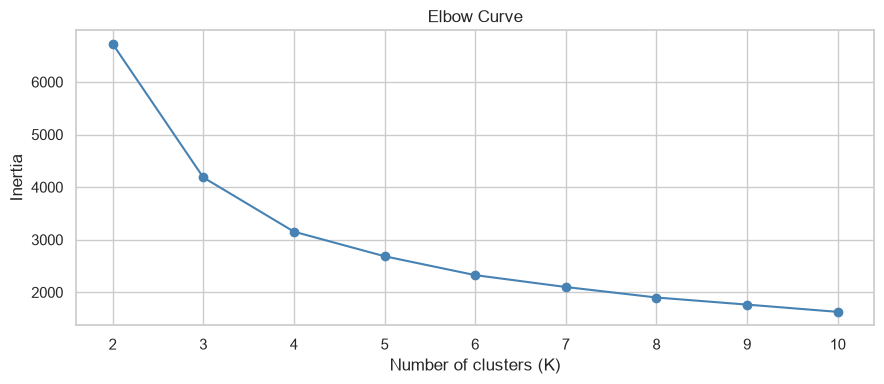

In [ ]:
inertias = [] ## Inertia tells us how compact a cluster is.
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

## 5. Silhouette scores

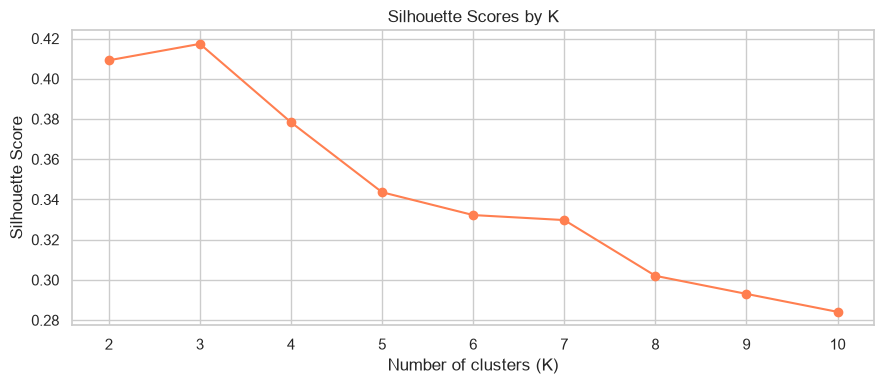

Best K by silhouette: 3  |  score: 0.4173


In [5]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(9, 4))
plt.plot(K_range, sil_scores, marker="o", color="coral")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by K")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best K by silhouette: {best_k}  |  score: {max(sil_scores):.4f}")

## 6. Cluster stability check
K-Means label assignment is non-deterministic across random seeds.  
Here we verify that the same customers consistently land in the same cluster — unstable segments are not actionable for a business.

We measure stability as the **mean pairwise Adjusted Rand Index (ARI)** across 10 runs.  
ARI = 1.0 means identical partitions; ARI > 0.90 is considered stable.

In [6]:
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

K = best_k  # use silhouette-optimal K; override below if elbow disagrees
N_RUNS = 10

all_labels = []
for seed in range(N_RUNS):
    km_tmp = KMeans(n_clusters=K, random_state=seed, n_init=10)
    all_labels.append(km_tmp.fit_predict(X_scaled))

ari_scores = [
    adjusted_rand_score(all_labels[i], all_labels[j])
    for i, j in combinations(range(N_RUNS), 2)
]
mean_ari = np.mean(ari_scores)
print(f"Mean ARI across {N_RUNS} runs (K={K}): {mean_ari:.4f}")
print("Stability verdict:", "STABLE ✓" if mean_ari > 0.90 else "UNSTABLE — consider different K ✗")

Mean ARI across 10 runs (K=3): 0.9974
Stability verdict: STABLE ✓


## 7. Fit final model
Using `best_k` from silhouette. If the elbow curve suggests a different K, set it explicitly below and document the reasoning.

In [7]:
# K = 4  # uncomment to override; document why if you do
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df["Segment"] = km.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df["Segment"])
print(f"Final model  |  K={K}  |  Silhouette={final_sil:.4f}")
print("\nSegment distribution:")
print(df["Segment"].value_counts().sort_index())

Final model  |  K=3  |  Silhouette=0.4173

Segment distribution:
Segment
0    2007
1    1318
2     965
Name: count, dtype: int64


## 8. Segment profiles
> Profiles are in **original units** (not log-space) for business readability.  
> **Recency = days since last purchase — lower is better.**  
> Inspect this table before assigning labels in the next cell.

In [8]:
profile = (
    df.groupby("Segment")[["Recency", "Frequency", "Monetary", "AOV"]]
    .mean()
    .round(2)
)
profile.rename(columns={"Recency": "Recency (days↓better)"}, inplace=True)
profile["Count"] = df.groupby("Segment").size()
profile["RevenueShare%"] = (
    df.groupby("Segment")["Monetary"].sum() / df["Monetary"].sum() * 100
).round(1)
profile = profile.sort_values("RevenueShare%", ascending=False)
print(profile.to_string())

         Recency (days↓better)  Frequency  Monetary     AOV  Count  RevenueShare%
Segment                                                                          
1                        29.98       9.57   4099.82  431.04   1318           78.4
0                        55.43       2.02    575.97  321.05   2007           16.8
2                       255.33       1.35    349.13  267.60    965            4.9


## 9. Label segments
**Assign labels only after inspecting the profile above.**  
Rule of thumb:
- Lowest Recency + Highest Monetary → **Champions**
- High Frequency but rising Recency → **At Risk**
- Medium across all → **Loyal Customers**
- Highest Recency + Lowest Monetary → **Lost / Inactive**

Update the mapping below to match your actual profile output.

In [9]:
# ── UPDATE THIS MAPPING based on profile output above ──
segment_labels = {
    1: "Champions",
    0: "Loyal Customers",
    2: "Lost / Inactive",
}

df["SegmentLabel"] = df["Segment"].map(segment_labels)

print("Segment label counts:")
print(df["SegmentLabel"].value_counts())

# Business punchline — put this in your README
print("\n--- Revenue Concentration ---")
rev = df.groupby("SegmentLabel")["Monetary"].sum().sort_values(ascending=False)
for seg, total in rev.items():
    pct = total / df["Monetary"].sum() * 100
    n   = (df["SegmentLabel"] == seg).sum()
    print(f"  {seg:<20} {pct:5.1f}% of revenue  |  {n:>5} customers")

Segment label counts:
SegmentLabel
Loyal Customers    2007
Champions          1318
Lost / Inactive     965
Name: count, dtype: int64

--- Revenue Concentration ---
  Champions             78.4% of revenue  |   1318 customers
  Loyal Customers       16.8% of revenue  |   2007 customers
  Lost / Inactive        4.9% of revenue  |    965 customers


## 10. PCA scatter — 2D visualisation

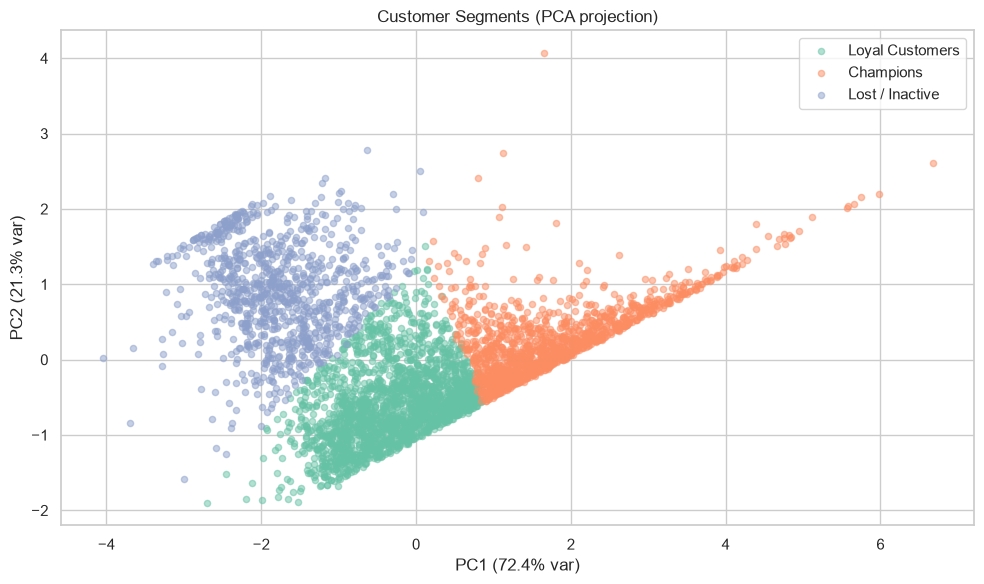

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", K)

for seg in range(K):
    mask = df["Segment"] == seg
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=segment_labels.get(seg, str(seg)),
        alpha=0.5, s=20, color=palette[seg],
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Customer Segments (PCA projection)")
plt.legend()
plt.tight_layout()
plt.show()

## 11. RFM box plots per segment

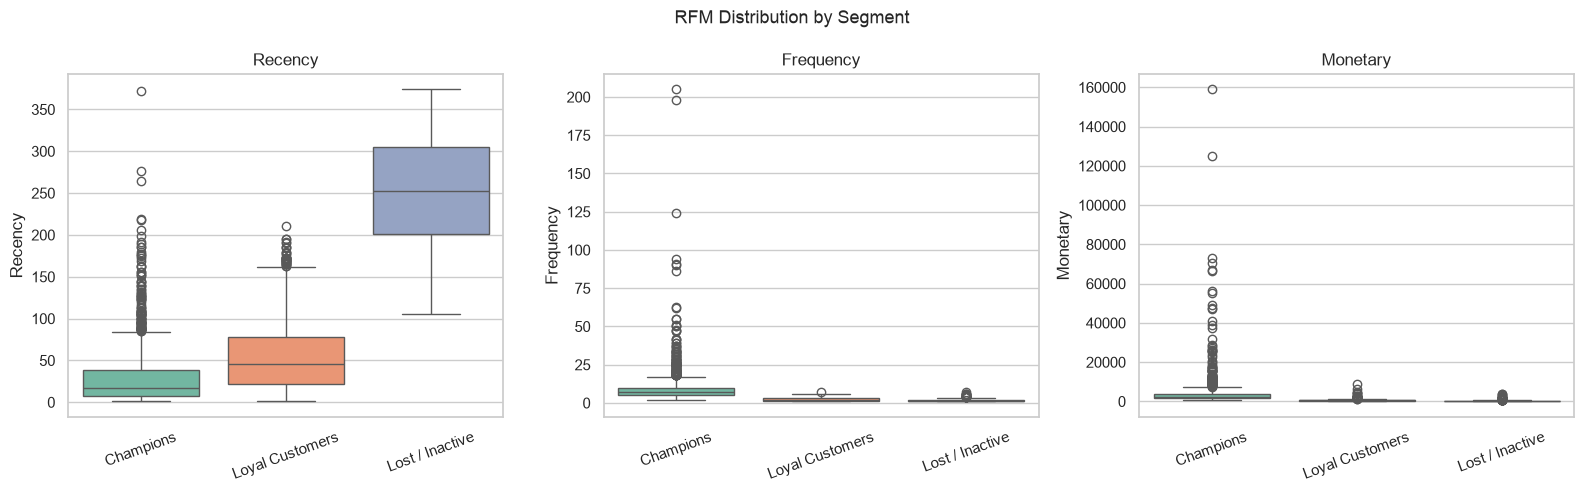

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(
        data=df, x="SegmentLabel", y=col,
        ax=ax, palette="Set2", order=list(segment_labels.values()),
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("RFM Distribution by Segment", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Segment classifier (supervised layer)
**Why:** K-Means must re-cluster the entire dataset to score a single new customer — that's not viable in production.  
A `RandomForestClassifier` trained on the cluster labels lets the inference API score any customer in O(log n) time with a single `.predict()` call.  
This is where the train/test split lives — it validates the classifier's ability to generalise, not the clustering itself.

In [ ]:
# Features available at inference time (no Segment/SegmentLabel)
df_clf = df.copy()

scaled_rfm = scaler.transform(df[rfm_cols])

df_clf["Recency_scaled"] = scaled_rfm[:,0]
df_clf["Log_Frequency_scaled"] = scaled_rfm[:,1]
df_clf["Log_Monetary_scaled"] = scaled_rfm[:,2]

FEATURE_COLS = [
    "Recency_scaled",
    "Log_Frequency_scaled",
    "Log_Monetary_scaled",
    "AOV"
]

X_clf = df[FEATURE_COLS].values
y_clf = df["Segment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
) ## stratify=y_clf ensures that the class distribution is preserved in both the training and testing sets, which is important for imbalanced datasets.

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Classification Report (segment classifier):")
print(classification_report(y_test, y_pred, target_names=[segment_labels[i] for i in sorted(segment_labels)]))

Classification Report (segment classifier):
                 precision    recall  f1-score   support

Loyal Customers       0.99      0.98      0.99       401
      Champions       0.99      1.00      0.99       264
Lost / Inactive       0.97      0.98      0.98       193

       accuracy                           0.99       858
      macro avg       0.98      0.99      0.99       858
   weighted avg       0.99      0.99      0.99       858



## 13. Feature importance — what drives segment membership?

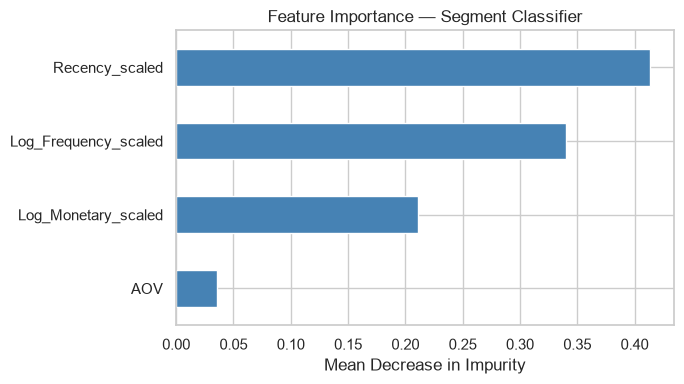

In [13]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Segment Classifier")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

## 14. Save artifacts

In [15]:
import json

ARTIFACTS = Path("../models/artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

joblib.dump(km,     ARTIFACTS / "kmeans.joblib")
joblib.dump(scaler, ARTIFACTS / "scaler_rfm.joblib")
joblib.dump(clf,    ARTIFACTS / "segment_classifier.joblib")

meta = {
    "k":               K,
    "silhouette":      round(final_sil, 4),
    "stability_ari":   round(mean_ari, 4),
    "rfm_cols":        rfm_cols,
    "feature_cols":    FEATURE_COLS,
    "segment_labels":  segment_labels,
}
with open(ARTIFACTS / "kmeans_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Artifacts saved:")
for p in sorted(ARTIFACTS.iterdir()):
    print(f"  {p.name}")

Artifacts saved:
  kmeans.joblib
  kmeans_meta.json
  scaler_rfm.joblib
  segment_classifier.joblib


## 15. Save segmented features

In [14]:
df.to_parquet("../data/processed/features_segmented.parquet", index=False)
print("Saved → data/processed/features_segmented.parquet")
print(f"Columns: {df.columns.tolist()}")

Saved → data/processed/features_segmented.parquet
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Log_Monetary', 'Log_Frequency', 'AOV', 'SpendStd', 'PreferredDayOfWeek', 'WeekendRatio', 'PreferredHour', 'UniqueSKUs', 'TotalItems', 'RepeatSKURatio', 'AvgGap', 'StdGap', 'ReturnRate', 'CohortMonth', 'ActiveMonths', 'DaysSinceFirstPurchase', 'Recency_scaled', 'Log_Frequency_scaled', 'Log_Monetary_scaled', 'Segment', 'SegmentLabel']
